In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("../data/wine_data.csv", header=None, usecols = [0, 1, 2])
df.columns = ["Class Label", "Alcohol", "Malic Acid"]

In [3]:
df.head(5)

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [4]:
#NOTE: Feature scaling is always done after all the feature engineering(missing val, outlier etc..) is done and before model training
#----- Feature scaling on missing values throws ValueError

In [5]:
X = df.iloc[:, 1:]
y = df["Class Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
X_train

,Alcohol,Malic Acid
138,13.49,3.59
104,12.51,1.73
78,12.33,0.99
36,13.28,1.64
93,12.29,2.83
...,...,...
71,13.86,1.51
106,12.25,1.73
14,14.38,1.87
92,12.69,1.53


In [7]:
scalar = MinMaxScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [8]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [9]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [10]:
#From above data, we can see that in min-max scaling -- the minimum value of each feature is 0 and the maximum value is 1.
#The mean and standard deviation are not fixed values, they depend on the distribution of the data.
#The data is scaled around the minimum and maximum values of each feature
#This can be useful for certain machine learning algorithms that are sensitive to the scale of the input features.

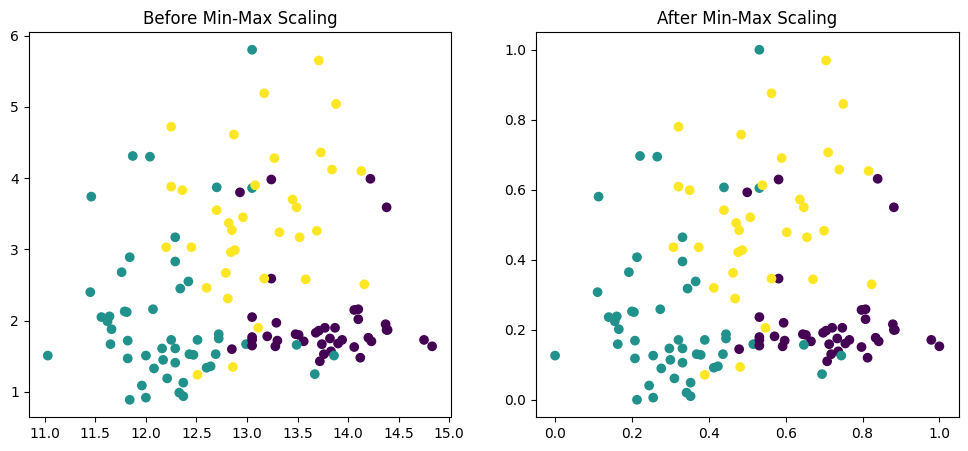

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train["Alcohol"], X_train["Malic Acid"], c=y_train)
ax1.set_title("Before Min-Max Scaling")
ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic Acid"], c=y_train)
ax2.set_title("After Min-Max Scaling")

plt.show()
#This shows that distribution of data remains same after scaling, but the range of values is changed to [0, 1]

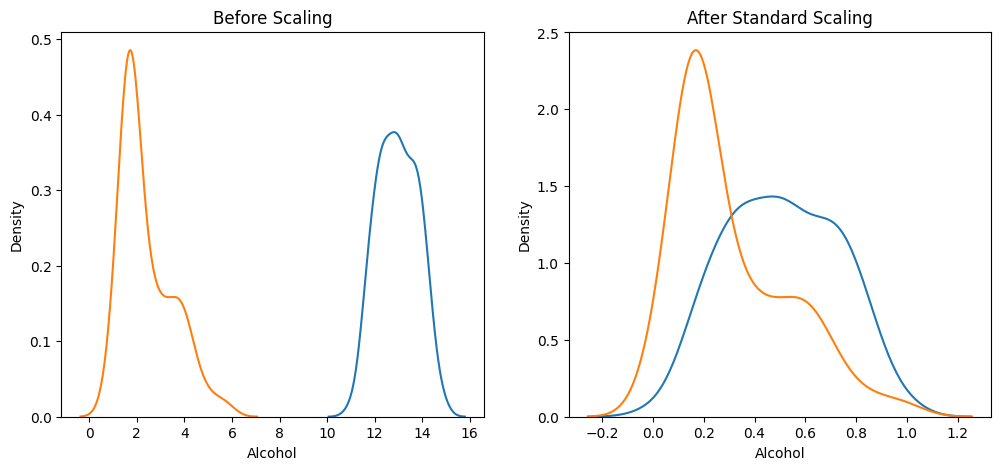

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

#This shows that after scaling, using kdeplots we can gather insights by comparing the distribution b/w features.
#Before scaling, we couldnt compare the distribution of the 2 features due to different scales. 

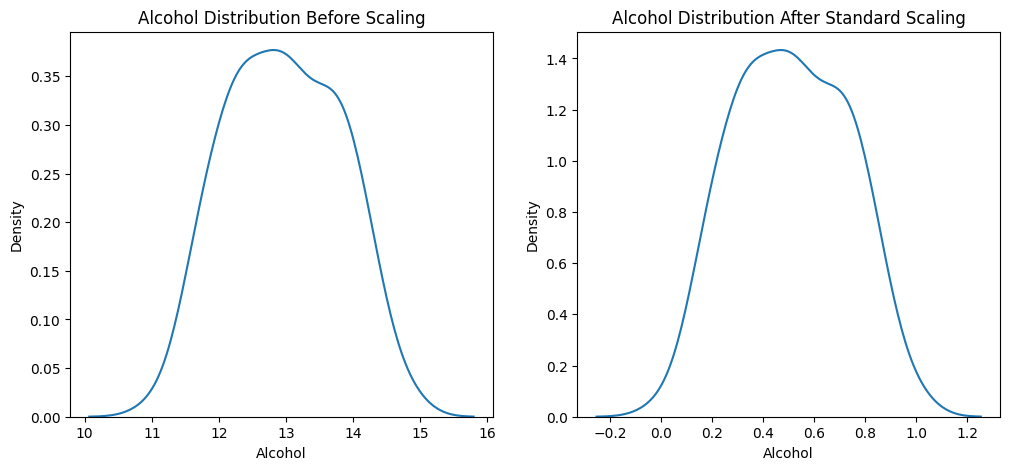

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

#This also shows that distribution remains same, only scales change with feature scaling.
#This is important to note that feature scaling does not change the distribution of the data, it only changes the scale of the features.